## Task 1

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE" # prevents OpenMP from crashing when multiple libs are loaded

In [2]:
from pathlib import Path

# Anchor everything to wherever this notebook is sitting
BASE_DIR = Path(".").resolve().parent
DATA_DIR = BASE_DIR / "multi_image_identities"
GALLERY_DIR = DATA_DIR / "multi_image_gallery" # reference images we search against
PROBE_DIR = DATA_DIR / "probe"  # query images we're trying to identify

print("BASE_DIR:", BASE_DIR)
print("GALLERY_DIR exists:", GALLERY_DIR.exists())
print("PROBE_DIR exists:", PROBE_DIR.exists())

BASE_DIR: /Users/radinabakalov/ironclad-radinabakalov
GALLERY_DIR exists: True
PROBE_DIR exists: True


In [ ]:
import sys
from pathlib import Path

# Add repo root to path (getting errors without this)
REPO_ROOT = Path(".").resolve().parent
sys.path.append(str(REPO_ROOT))

print("Added to sys.path:", REPO_ROOT)

Added to sys.path: /Users/radinabakalov/ironclad-radinabakalov


In [4]:
def count_images(root: Path, exts={".jpg", ".jpeg", ".png"}):
    # Each subdirectory under root is one identity (i.e. one person/subject)
    identities = [p for p in root.iterdir() if p.is_dir()]
    n_ids = len(identities)

    # Count all image files across every identity folder
    n_imgs = 0
    for ident in identities:
        n_imgs += sum(1 for f in ident.iterdir() if f.suffix.lower() in exts)
    return n_ids, n_imgs

gallery_ids, gallery_imgs = count_images(GALLERY_DIR)
probe_ids, probe_imgs = count_images(PROBE_DIR)

print(f"Gallery: {gallery_ids} identities, {gallery_imgs} images")
print(f"Probe:   {probe_ids} identities, {probe_imgs} images")

# Gallery and probe should cover the exact same set of identities
gallery_names = sorted([p.name for p in GALLERY_DIR.iterdir() if p.is_dir()])
probe_names = sorted([p.name for p in PROBE_DIR.iterdir() if p.is_dir()])
print("Same identity sets:", gallery_names == probe_names)

Gallery: 1000 identities, 2265 images
Probe:   1000 identities, 999 images
Same identity sets: True


In [5]:
from PIL import Image

# Grab the first identity alphabetically just to have a consistent test subject
identity_name = sorted([p.name for p in GALLERY_DIR.iterdir() if p.is_dir()])[0]

# Pick the first image from that identity in both gallery and probe
gallery_img_path = sorted((GALLERY_DIR / identity_name).glob("*.jpg"))[0]
probe_img_path = sorted((PROBE_DIR / identity_name).glob("*.jpg"))[0]

print("Identity:", identity_name)
print("Gallery image:", gallery_img_path.name)
print("Probe image:", probe_img_path.name)

# Convert to RGB just in case the image is grayscale or has an alpha channel
gallery_img = Image.open(gallery_img_path).convert("RGB")
probe_img = Image.open(probe_img_path).convert("RGB")

gallery_img.size, probe_img.size

Identity: Aaron_Sorkin
Gallery image: Aaron_Sorkin_0001.jpg
Probe image: Aaron_Sorkin_0002.jpg


((250, 250), (250, 250))

In [6]:
import numpy as np

from ironclad.modules.extraction.preprocessing import Preprocessing
from ironclad.modules.extraction.embedding import Embedding

# Resize images to 224x224 (standard input size for most face recognition models)
pre = Preprocessing(image_size=224)

# Load two pretrained face embedding models so we can compare their performance
model_casia = Embedding(pretrained="casia-webface", device=pre.device) # trained on CASIA-WebFace dataset
model_vgg = Embedding(pretrained="vggface2", device=pre.device) # trained on VGGFace2 dataset

# Preprocess both images into tensors the models can actually consume
gallery_tensor = pre.process(gallery_img)
probe_tensor = pre.process(probe_img)

# Encode each image into a 512-dimensional face embedding vector
g_casia = model_casia.encode(gallery_tensor).astype(np.float32)
p_casia = model_casia.encode(probe_tensor).astype(np.float32)

g_vgg = model_vgg.encode(gallery_tensor).astype(np.float32)
p_vgg = model_vgg.encode(probe_tensor).astype(np.float32)

# Should both print (512,) 
print("CASIA shapes:", g_casia.shape, p_casia.shape)
print("VGG shapes:", g_vgg.shape, p_vgg.shape)

/Users/radinabakalov/ironclad-radinabakalov/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CASIA shapes: (512,) (512,)
VGG shapes: (512,) (512,)


In [7]:
def cosine_sim(a, b):
    a = np.asarray(a, dtype=np.float32)
    b = np.asarray(b, dtype=np.float32)

    # Denominator is the product of both vectors' magnitudes
    denom = (np.linalg.norm(a) * np.linalg.norm(b))

    # If either vector is all zeros, similarity is undefined -> return 0 to be safe
    if denom == 0:
        return 0.0
    
    # Dot product divided by magnitudes gives a score between -1 and 1
    return float(np.dot(a, b) / denom)

# 1.0 = identical direction, 0.0 = orthogonal, negative = opposite - higher is more similar
print("Cosine similarity (CASIA):", cosine_sim(g_casia, p_casia))
print("Cosine similarity (VGG):", cosine_sim(g_vgg, p_vgg))

Cosine similarity (CASIA): 0.6642414927482605
Cosine similarity (VGG): 0.6333585381507874


In [8]:
# !pip install tqdm

In [9]:
import tqdm
from tqdm import tqdm

def build_gallery_embeddings(model):
    gallery_embeddings = []
    gallery_labels = []
    
    # Walk through each identity folder in the gallery (one folder = one person)
    for identity_dir in sorted(GALLERY_DIR.iterdir()):
        if not identity_dir.is_dir():
            continue # skip any stray files that aren't folders

        identity = identity_dir.name

        # Encode every image for this identity and store it alongside its label
        for img_path in identity_dir.glob("*.jpg"):
            img = Image.open(img_path).convert("RGB")
            tensor = pre.process(img)
            emb = model.encode(tensor).astype(np.float32)

            gallery_embeddings.append(emb)
            gallery_labels.append(identity)

    # Stack all embeddings into a single matrix -> shape: (total_images, embedding_dim)
    return np.vstack(gallery_embeddings), gallery_labels


print("Building CASIA gallery embeddings...")
gallery_emb_casia, gallery_labels = build_gallery_embeddings(model_casia)

print("Building VGG gallery embeddings...")
gallery_emb_vgg, _ = build_gallery_embeddings(model_vgg) # labels are the same, no need to store twice

# Should be (num_gallery_images, 512) for both
print("Gallery shape (CASIA):", gallery_emb_casia.shape)
print("Gallery shape (VGG):", gallery_emb_vgg.shape)

Building CASIA gallery embeddings...
Building VGG gallery embeddings...
Gallery shape (CASIA): (2265, 512)
Gallery shape (VGG): (2265, 512)


In [10]:
def evaluate_model(model, gallery_embs, gallery_labels, top_k=5):
    correct_top1 = 0 # did the #1 match get it right?
    correct_topk = 0 # did the correct identity appear anywhere in the top-k?
    total = 0
    
    # Run every probe image through the model and compare against the gallery
    for identity_dir in sorted(PROBE_DIR.iterdir()):
        if not identity_dir.is_dir():
            continue

        identity = identity_dir.name

        for img_path in identity_dir.glob("*.jpg"):
            img = Image.open(img_path).convert("RGB")
            tensor = pre.process(img)
            probe_emb = model.encode(tensor).astype(np.float32)

            # Compute cosine similarity between this probe and every gallery embedding at once
            sims = gallery_embs @ probe_emb
            norms = np.linalg.norm(gallery_embs, axis=1) * np.linalg.norm(probe_emb)
            sims = sims / norms # normalize to get proper cosine scores in [-1, 1]

            # Rank gallery images from most to least similar and grab the top-k
            top_indices = np.argsort(-sims)[:top_k]
            top_labels = [gallery_labels[i] for i in top_indices]

            # Top-1: was the single best match the right person?
            if top_labels[0] == identity:
                correct_top1 += 1
            # Top-k: did the right person appear anywhere in the top-k results?
            if identity in top_labels:
                correct_topk += 1

            total += 1

    return correct_top1 / total, correct_topk / total


print("Evaluating CASIA...")
casia_top1, casia_top5 = evaluate_model(model_casia, gallery_emb_casia, gallery_labels)

print("Evaluating VGG...")
vgg_top1, vgg_top5 = evaluate_model(model_vgg, gallery_emb_vgg, gallery_labels)

print("\nResults:")
print(f"CASIA Top-1: {casia_top1:.4f}, Top-5: {casia_top5:.4f}")
print(f"VGG Top-1: {vgg_top1:.4f}, Top-5: {vgg_top5:.4f}")

Evaluating CASIA...
Evaluating VGG...

Results:
CASIA Top-1: 0.3654, Top-5: 0.5185
VGG Top-1: 0.7087, Top-5: 0.8358


In [11]:
from PIL import ImageFilter, ImageEnhance

def apply_blur(img, radius=2):
    # Simulate an out-of-focus or low-quality camera shot
    return img.filter(ImageFilter.GaussianBlur(radius))

def apply_brightness(img, factor=0.6):
    # factor < 1 darkens, factor > 1 brightens -> 0.6 simulates poor lighting
    enhancer = ImageEnhance.Brightness(img)
    return enhancer.enhance(factor)

def apply_resize(img, scale=0.5):
    w, h = img.size
    # Shrink the image down then blow it back up -> this intentionally degrades quality
    # To simulate a low-resolution source image
    img_small = img.resize((int(w*scale), int(h*scale)))
    return img_small.resize((w, h))

In [12]:
def evaluate_with_transform(model, gallery_embs, gallery_labels, transform=None, top_k=5):
    correct_top1 = 0
    correct_topk = 0
    total = 0

    for identity_dir in sorted(PROBE_DIR.iterdir()):
        if not identity_dir.is_dir():
            continue

        identity = identity_dir.name

        for img_path in identity_dir.glob("*.jpg"):
            img = Image.open(img_path).convert("RGB")

            # Apply the degradation (blur, brightness, resize) if one was passed in
            if transform:
                img = transform(img)

            tensor = pre.process(img)
            probe_emb = model.encode(tensor).astype(np.float32)

            # Vectorized cosine similarity against the entire gallery at once
            sims = gallery_embs @ probe_emb
            norms = np.linalg.norm(gallery_embs, axis=1) * np.linalg.norm(probe_emb)
            sims = sims / norms

            # Rank by similarity (descending) and grab the top-k identities
            top_indices = np.argsort(-sims)[:top_k]
            top_labels = [gallery_labels[i] for i in top_indices]

            # Top-1: best match is correct?
            if top_labels[0] == identity:
                correct_top1 += 1
            # Top-k: correct identity appears anywhere in top-k?
            if identity in top_labels:
                correct_topk += 1

            total += 1

    return correct_top1 / total, correct_topk / total

In [ ]:
# Run robustness tests on VGG 

# Test how well VGG handles blurry probe images
print("Blur test:")
blur_top1, blur_top5 = evaluate_with_transform(
    model_vgg, gallery_emb_vgg, gallery_labels,
    transform=lambda img: apply_blur(img, radius=2)
)

# Test robustness to darker / underexposed images
print("Brightness test:")
bright_top1, bright_top5 = evaluate_with_transform(
    model_vgg, gallery_emb_vgg, gallery_labels,
    transform=lambda img: apply_brightness(img, factor=0.6)
)

# Test how much accuracy drops when images are downscaled and upscaled back
print("Resize test:")
resize_top1, resize_top5 = evaluate_with_transform(
    model_vgg, gallery_emb_vgg, gallery_labels,
    transform=lambda img: apply_resize(img, scale=0.5)
)

# Compare all three degradations side by side
print("\nRobustness Results (VGG):")
print(f"Blur Top-1: {blur_top1:.4f}, Top-5: {blur_top5:.4f}")
print(f"Bright Top-1: {bright_top1:.4f}, Top-5: {bright_top5:.4f}")
print(f"Resize Top-1: {resize_top1:.4f}, Top-5: {resize_top5:.4f}")

Blur test:
Brightness test:
Resize test:

Robustness Results (VGG):
Blur Top-1: 0.5916, Top-5: 0.7508
Bright Top-1: 0.5676, Top-5: 0.7167
Resize Top-1: 0.6957, Top-5: 0.8258


In [15]:
# Run robustness tests on CASIA (same transforms we used for VGG)

# Test how well VGG handles blurry probe images
print("CASIA Blur test:")
casia_blur_top1, casia_blur_top5 = evaluate_with_transform(
    model_casia, gallery_emb_casia, gallery_labels,
    transform=lambda img: apply_blur(img, radius=2)
)

# Test robustness to darker / underexposed images
print("CASIA Brightness test:")
casia_bright_top1, casia_bright_top5 = evaluate_with_transform(
    model_casia, gallery_emb_casia, gallery_labels,
    transform=lambda img: apply_brightness(img, factor=0.6)
)

# Test how much accuracy drops when images are downscaled and upscaled back
print("CASIA Resize test:")
casia_resize_top1, casia_resize_top5 = evaluate_with_transform(
    model_casia, gallery_emb_casia, gallery_labels,
    transform=lambda img: apply_resize(img, scale=0.5)
)

# Compare all three degradations side by side
print("\nRobustness Results (CASIA):")
print(f"Blur Top-1: {casia_blur_top1:.4f}, Top-5: {casia_blur_top5:.4f}")
print(f"Bright Top-1: {casia_bright_top1:.4f}, Top-5: {casia_bright_top5:.4f}")
print(f"Resize Top-1: {casia_resize_top1:.4f}, Top-5: {casia_resize_top5:.4f}")

CASIA Blur test:
CASIA Brightness test:
CASIA Resize test:

Robustness Results (CASIA):
Blur Top-1: 0.2432, Top-5: 0.3884
Bright Top-1: 0.1792, Top-5: 0.2693
Resize Top-1: 0.3544, Top-5: 0.5015


In [16]:
# Collect all results in one place for easy reference
results = {
    "CASIA": {
        "baseline": {"top1": casia_top1, "top5": casia_top5},
        "blur": {"top1": casia_blur_top1, "top5": casia_blur_top5},
        "brightness": {"top1": casia_bright_top1, "top5": casia_bright_top5},
        "resize": {"top1": casia_resize_top1, "top5": casia_resize_top5},
    },
    "VGG": {
        "baseline": {"top1": vgg_top1, "top5": vgg_top5},
        "blur": {"top1": blur_top1, "top5": blur_top5},
        "brightness": {"top1": bright_top1, "top5": bright_top5},
        "resize": {"top1": resize_top1, "top5": resize_top5},
    }
}

print("Results dictionary built!")

Results dictionary built!


In [18]:
# Print a comparison of all results
conditions = ["baseline", "blur", "brightness", "resize"]

print("MODEL COMPARISON ACROSS ALL CONDITIONS")

for condition in conditions:
    casia_t1 = results["CASIA"][condition]["top1"]
    casia_t5 = results["CASIA"][condition]["top5"]
    vgg_t1 = results["VGG"][condition]["top1"]
    vgg_t5 = results["VGG"][condition]["top5"]
    
    diff_t1 = vgg_t1 - casia_t1
    diff_t5 = vgg_t5 - casia_t5
    
    print(f"\n{condition.upper()}:")
    print(f"  CASIA - Top-1: {casia_t1:.4f}, Top-5: {casia_t5:.4f}")
    print(f"  VGG - Top-1: {vgg_t1:.4f}, Top-5: {vgg_t5:.4f}")
    print(f"  Difference (VGG - CASIA): Top-1: +{diff_t1:.4f}, Top-5: +{diff_t5:.4f}")

MODEL COMPARISON ACROSS ALL CONDITIONS

BASELINE:
  CASIA - Top-1: 0.3654, Top-5: 0.5185
  VGG - Top-1: 0.7087, Top-5: 0.8358
  Difference (VGG - CASIA): Top-1: +0.3433, Top-5: +0.3173

BLUR:
  CASIA - Top-1: 0.2432, Top-5: 0.3884
  VGG - Top-1: 0.5916, Top-5: 0.7508
  Difference (VGG - CASIA): Top-1: +0.3483, Top-5: +0.3624

BRIGHTNESS:
  CASIA - Top-1: 0.1792, Top-5: 0.2693
  VGG - Top-1: 0.5676, Top-5: 0.7167
  Difference (VGG - CASIA): Top-1: +0.3884, Top-5: +0.4474

RESIZE:
  CASIA - Top-1: 0.3544, Top-5: 0.5015
  VGG - Top-1: 0.6957, Top-5: 0.8258
  Difference (VGG - CASIA): Top-1: +0.3413, Top-5: +0.3243


In [19]:
import matplotlib.pyplot as plt

# Create figures directory if it doesn't exist
figures_dir = BASE_DIR / "analysis" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {figures_dir}")

Figures will be saved to: /Users/radinabakalov/ironclad-radinabakalov/analysis/figures


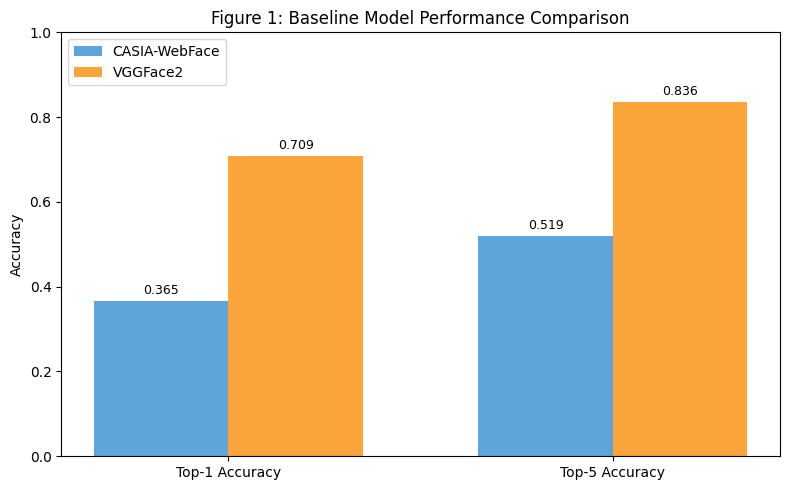

Saved: /Users/radinabakalov/ironclad-radinabakalov/analysis/figures/model_baseline_comparison.png


In [20]:
# Figure 1: Baseline Model Comparison

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(2) # Top-1 and Top-5
width = 0.35

casia_vals = [casia_top1, casia_top5]
vgg_vals = [vgg_top1, vgg_top5]

bars1 = ax.bar(x - width/2, casia_vals, width, label='CASIA-WebFace', color='#5DA5DA')
bars2 = ax.bar(x + width/2, vgg_vals, width, label='VGGFace2', color='#FAA43A')

ax.set_ylabel('Accuracy')
ax.set_title('Figure 1: Baseline Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(['Top-1 Accuracy', 'Top-5 Accuracy'])
ax.legend()
ax.set_ylim(0, 1.0)

# Add value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(figures_dir / "model_baseline_comparison.png", dpi=150)
plt.show()

print(f"Saved: {figures_dir / 'model_baseline_comparison.png'}")

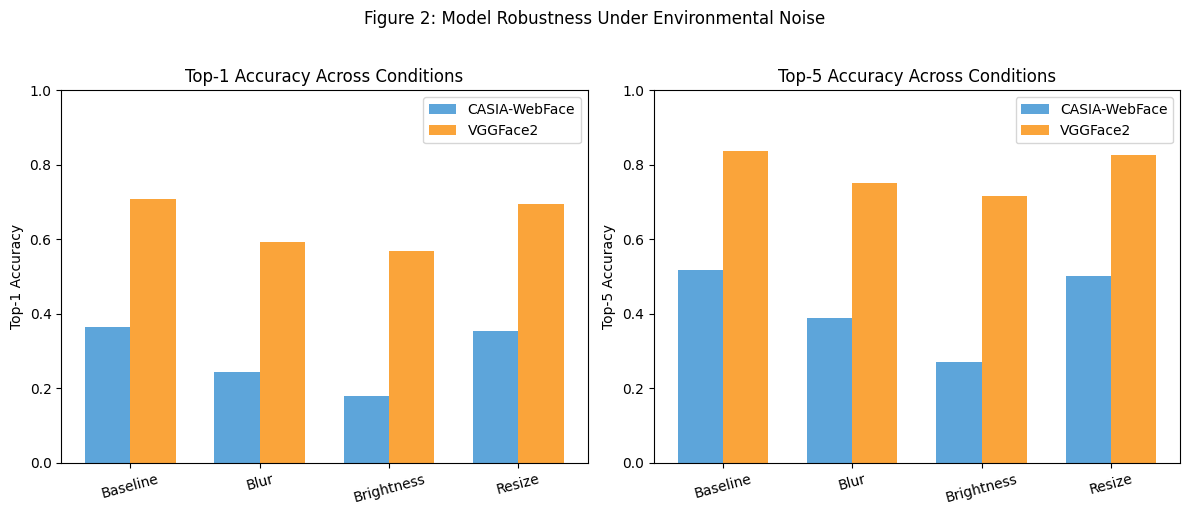

Saved: /Users/radinabakalov/ironclad-radinabakalov/analysis/figures/model_robustness_comparison.png


In [21]:
# Figure 2: Robustness across all conditions

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

conditions = ["Baseline", "Blur", "Brightness", "Resize"]
x = np.arange(len(conditions))
width = 0.35

# Top-1 subplot
ax1 = axes[0]
casia_t1_vals = [results["CASIA"][c.lower()]["top1"] for c in conditions]
vgg_t1_vals = [results["VGG"][c.lower()]["top1"] for c in conditions]

ax1.bar(x - width/2, casia_t1_vals, width, label='CASIA-WebFace', color='#5DA5DA')
ax1.bar(x + width/2, vgg_t1_vals, width, label='VGGFace2', color='#FAA43A')
ax1.set_ylabel('Top-1 Accuracy')
ax1.set_title('Top-1 Accuracy Across Conditions')
ax1.set_xticks(x)
ax1.set_xticklabels(conditions, rotation=15)
ax1.legend()
ax1.set_ylim(0, 1.0)

# Top-5 subplot
ax2 = axes[1]
casia_t5_vals = [results["CASIA"][c.lower()]["top5"] for c in conditions]
vgg_t5_vals = [results["VGG"][c.lower()]["top5"] for c in conditions]

ax2.bar(x - width/2, casia_t5_vals, width, label='CASIA-WebFace', color='#5DA5DA')
ax2.bar(x + width/2, vgg_t5_vals, width, label='VGGFace2', color='#FAA43A')
ax2.set_ylabel('Top-5 Accuracy')
ax2.set_title('Top-5 Accuracy Across Conditions')
ax2.set_xticks(x)
ax2.set_xticklabels(conditions, rotation=15)
ax2.legend()
ax2.set_ylim(0, 1.0)

plt.suptitle('Figure 2: Model Robustness Under Environmental Noise', y=1.02)
plt.tight_layout()
plt.savefig(figures_dir / "model_robustness_comparison.png", dpi=150)
plt.show()

print(f"Saved: {figures_dir / 'model_robustness_comparison.png'}")

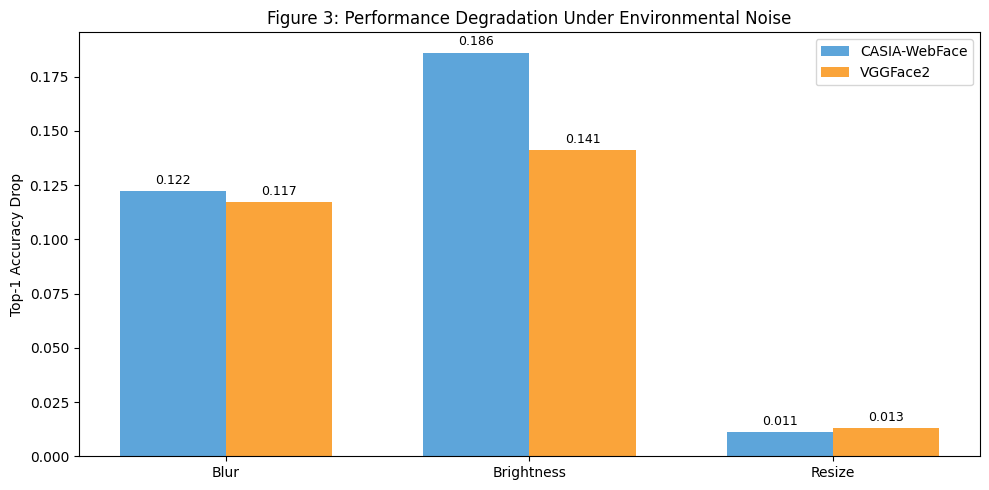

Saved: /Users/radinabakalov/ironclad-radinabakalov/analysis/figures/model_degradation_comparison.png


In [22]:
# Figure 3: How much does each model degrade under noise?

fig, ax = plt.subplots(figsize=(10, 5))

degradations = ["Blur", "Brightness", "Resize"]
x = np.arange(len(degradations))
width = 0.35

# Calculate drop from baseline for each model
casia_drops = []
vgg_drops = []

for cond in degradations:
    casia_baseline = results["CASIA"]["baseline"]["top1"]
    casia_degraded = results["CASIA"][cond.lower()]["top1"]
    casia_drops.append(casia_baseline - casia_degraded)
    
    vgg_baseline = results["VGG"]["baseline"]["top1"]
    vgg_degraded = results["VGG"][cond.lower()]["top1"]
    vgg_drops.append(vgg_baseline - vgg_degraded)

bars1 = ax.bar(x - width/2, casia_drops, width, label='CASIA-WebFace', color='#5DA5DA')
bars2 = ax.bar(x + width/2, vgg_drops, width, label='VGGFace2', color='#FAA43A')

ax.set_ylabel('Top-1 Accuracy Drop')
ax.set_title('Figure 3: Performance Degradation Under Environmental Noise')
ax.set_xticks(x)
ax.set_xticklabels(degradations)
ax.legend()

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(figures_dir / "model_degradation_comparison.png", dpi=150)
plt.show()

print(f"Saved: {figures_dir / 'model_degradation_comparison.png'}")

In [30]:
# Save everything so we can reload without re-running
import pickle

results_path = BASE_DIR / "analysis" / "task1_results.pkl"
with open(results_path, "wb") as f:
    pickle.dump(results, f)

print(f"Results saved to: {results_path}")

Results saved to: /Users/radinabakalov/ironclad-radinabakalov/analysis/task1_results.pkl
